In [1]:
import geopandas as gpd
import pandas as pd
import warnings
import os
import glob
import subprocess
import cartopy.io.shapereader as shpreader
import xarray as xr
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rioxarray as rxr
import matplotlib.patches as mpatches
from cartopy.feature import NaturalEarthFeature
from matplotlib.patches import Rectangle
from pyproj import Transformer
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pyproj import CRS, Transformer
import geopandas as gpd
from shapely.geometry import Point
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
os.environ['PROJ_LIB'] = '/home/annierosen16/anaconda3/envs/firedpy_env312/share/proj'

### loading MODIS land-cover type

In [2]:
# converting all hdf files into tifs -> subprocess

hdf_files = sorted(glob.glob('/home/annierosen16/wildfire_ml/landcover/*.hdf'))

tif_dir = '/home/annierosen16/wildfire_ml/landcover/tifs'

os.makedirs(tif_dir, exist_ok=True)

for hdf in hdf_files:
    
    basename = os.path.basename(hdf).replace('.hdf', '.tif')
    
    output_tif = os.path.join(tif_dir, basename)
    
    if os.path.exists(output_tif):
        
        continue
    
    subdataset = f'HDF4_EOS:EOS_GRID:"{hdf}":MCD12Q1:LC_Type1'
    
    subprocess.run(['gdal_translate', subdataset, output_tif],
                   
                   capture_output=True)

print("Done!")

Done!


In [3]:
tif_dir = '/home/annierosen16/wildfire_ml/landcover/tifs'

# IGBP land cover code to name mapping

igbp_names = {
    
    1: 'Evergreen Needleleaf Forests',
    
    2: 'Evergreen Broadleaf Forests',
    
    3: 'Deciduous Needleleaf Forests',
    
    4: 'Deciduous Broadleaf Forests',
    
    5: 'Mixed Forests',
    
    6: 'Closed Shrublands',
    
    7: 'Open Shrublands',
    
    8: 'Woody Savannas',
    
    9: 'Savannas',
    
    10: 'Grasslands',
    
    11: 'Permanent Wetlands',
    
    12: 'Croplands',
    
    13: 'Urban and Built-up Lands',
    
    14: 'Cropland/Natural Vegetation Mosaics',
    
    15: 'Permanent Snow and Ice',
    
    16: 'Barren',
    
    17: 'Water Bodies',
    
    255: 'Unclassified'}

# tile lookup based on x coordinate ranges

def get_tile(x, y):
   
    """Determine which MODIS tile an x,y sinusoidal coordinate falls in"""
    
    tiles = {
        
        'h08v04': (-1.112e+07, -1.001e+07, 4.448e+06, 5.560e+06),
        
        'h08v05': (-1.112e+07, -1.001e+07, 3.336e+06, 4.448e+06),
        
        'h09v04': (-1.001e+07, -8.896e+06, 4.448e+06, 5.560e+06),
        
        'h09v05': (-1.001e+07, -8.896e+06, 3.336e+06, 4.448e+06),
        
        'h10v04': (-8.896e+06, -7.784e+06, 4.448e+06, 5.560e+06),
        
        'h10v05': (-8.896e+06, -7.784e+06, 3.336e+06, 4.448e+06),
        
        'h11v04': (-7.784e+06, -6.672e+06, 4.448e+06, 5.560e+06),
        
        'h11v05': (-7.784e+06, -6.672e+06, 3.336e+06, 4.448e+06),
        
        'h12v04': (-6.672e+06, -5.560e+06, 4.448e+06, 5.560e+06),
        
        'h12v05': (-6.672e+06, -5.560e+06, 3.336e+06, 4.448e+06)}
    
    for tile, (xmin, xmax, ymin, ymax) in tiles.items():
        
        if xmin <= x <= xmax and ymin <= y <= ymax:
            
            return tile
    
    return None

# load all tifs into a dictionary keyed by (tile, year)

print("Loading landcover tifs...")

lc_cache = {}

for tif in sorted(glob.glob(os.path.join(tif_dir, '*.tif'))):
    
    basename = os.path.basename(tif)
    
    # MCD12Q1.A2001001.h08v04.061.*.tif
    
    parts = basename.split('.')
    
    year = int(parts[1][1:5])
    
    tile = parts[2]
    
    lc_cache[(tile, year)] = rxr.open_rasterio(tif).squeeze()

print(f"Loaded {len(lc_cache)} tile-year combinations")

Loading landcover tifs...
Loaded 240 tile-year combinations


### loading daily (from firedpy version 1)

In [4]:
with warnings.catch_warnings():
    
    warnings.simplefilter('ignore')
    
    daily = gpd.read_file('/home/annierosen16/wildfire_ml/fired_conus_v1_2025/outputs/shapefiles/conus_to2022335_daily.gpkg')

print(f"Total unique fires: {daily['id'].nunique()}")

# confirming max growth in hectares of all fires is 215,208 ha/day

print(f"Max mx_grw_km2 in ha: {daily['mx_grw_km2'].max() * 100:.1f}")

Total unique fires: 97515
Max mx_grw_km2 in ha: 214207.9


### filtering daily to CONUS 

In [5]:
modis_sinu = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"

transformer = Transformer.from_crs(modis_sinu, "EPSG:4326", always_xy=True)

# one row per fire

all_fires = daily.drop_duplicates(subset=['id']).copy()

all_fires['mx_grw_ha'] = all_fires['mx_grw_km2'] * 100

# convert to lat/lon

lons_all, lats_all = transformer.transform(all_fires['x'].values, all_fires['y'].values)

all_fires['lon'] = lons_all

all_fires['lat'] = lats_all

# filter to western US directly

all_fires_west = all_fires[
    
    (all_fires['lon'] >= -125) & (all_fires['lon'] <= -99) &
    
    (all_fires['lat'] >= 25) & (all_fires['lat'] <= 50)].copy()

print(f"Western US fires: {len(all_fires_west)}")

Western US fires: 43699


In [6]:
def get_landcover(x, y, ig_year):
    
    """Get IGBP landcover code for a fire pixel using the year before ignition"""
    
    lc_year = ig_year - 1
    
    # clamp to available range
    
    lc_year = max(2001, min(2019, lc_year))
    
    tile = get_tile(x, y)
    
    if tile is None:
        
        return 255, 'Unclassified'
    
    key = (tile, lc_year)
    
    if key not in lc_cache:
        
        return 255, 'Unclassified'
    
    da = lc_cache[key]
    
    # find nearest pixel
    
    lc_code = int(da.sel(x=x, y=y, method='nearest').values)
    
    lc_name = igbp_names.get(lc_code, 'Unclassified')
    
    return lc_code, lc_name

print("Assigning landcover to fires...")

all_fires_west[['lc_code', 'lc_name']] = all_fires_west.apply(
    
    lambda row: pd.Series(get_landcover(row['x'], row['y'], row['ig_year'])),
    
    axis=1)

print("Done!")

print(all_fires_west['lc_name'].value_counts().head(10))

Assigning landcover to fires...
Done!
lc_name
Grasslands                      18929
Croplands                       14339
Evergreen Needleleaf Forests     2782
Woody Savannas                   2208
Savannas                         1798
Open Shrublands                  1756
Barren                            931
Closed Shrublands                 359
Urban and Built-up Lands          129
Mixed Forests                     101
Name: count, dtype: int64


### filtering out croplands

In [7]:
## filter out cropland

cropland_types = ['Croplands', 'Cropland/Natural Vegetation Mosaics']

all_fires_west = all_fires_west[~all_fires_west['lc_name'].isin(cropland_types)]

print(f"Unique fires: {all_fires_west['id'].nunique()}")

Unique fires: 29312


### converting all x, y points to lat / lons

In [8]:
all_fires_west['date'] = pd.to_datetime(all_fires_west['date'])

# -----------------------------
# 2. MODIS sinusoidal -> lon/lat
# -----------------------------

modis_crs = CRS.from_proj4("+proj=sinu +R=6371007.181 +nadgrids=@null +wktext")

geo_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(modis_crs, geo_crs, always_xy=True)

# x = projection_x_coordinate (m), y = projection_y_coordinate (m)

lon, lat = transformer.transform(all_fires_west['x'].values, all_fires_west['y'].values)

all_fires_west = all_fires_west.copy()

all_fires_west['lon'] = lon

all_fires_west['lat'] = lat

### confirming august complex contains about 1 million acres burned area total

In [9]:
# -----------------------------
# 3. Define August Complex window
# -----------------------------

start_date = pd.Timestamp("2020-08-16")

end_date   = pd.Timestamp("2020-11-12")

lon_min, lon_max = -123.7, -121.5

lat_min, lat_max = 39.3, 41.3

# -----------------------------
# 4. Filter by date + bounding box
# -----------------------------

august_complex = all_fires_west[
    
    (all_fires_west['date'] >= start_date) &
    
    (all_fires_west['date'] <= end_date) &
    
    (all_fires_west['lon'] >= lon_min) &
    
    (all_fires_west['lon'] <= lon_max) &
    
    (all_fires_west['lat'] >= lat_min) &
    
    (all_fires_west['lat'] <= lat_max)].copy()

august_complex['tot_ar_acres'] = august_complex['tot_ar_km2'] * 247.105

total_acres = august_complex.drop_duplicates(subset=['id'])['tot_ar_acres'].sum()

print(f"Total acres: {total_acres:,.0f}")

Total acres: 1,099,586


### defining fast_fgr which are fires that have a max growth rate of > 1620 ha/day 

In [10]:
# define fast fgr threshold

threshold = 1620 # ha/day

all_fires_west['mx_grw_ha'] = all_fires_west['mx_grw_km2'] * 100

# filter for fires exceeding threshold

fast_fgr = all_fires_west[all_fires_west['mx_grw_ha'] > threshold].copy()

print(f"Fires exceeding {threshold} ha/day: {len(fast_fgr)}")

Fires exceeding 1620 ha/day: 1456


### defining top 100 from fast_fgr

In [11]:
# top 100 fastest

top100 = (fast_fgr
        
        .sort_values('mx_grw_ha', ascending=False)
        
        .head(100)[['id', 'date', 'ig_date', 'mx_grw_dte','ig_year', 'pixels', 'dy_ar_km2', 'mx_grw_ha', 'tot_ar_km2', 'event_dur', 'x', 'y']])

### uploading circulation patterns (500 hpa)

In [76]:
geopath = "/data/rong4/yzhuang/Data/ERA5_1deg/geopotential"

g = 9.81  # m/s2

# build list of files — JJAS only

files = []

for year in range(1979, 2023):
    
    for month in [6, 7, 8, 9]:
        
        fname = f"era5.geopotential.{year}{month:02d}.nc"
        
        fpath = os.path.join(geopath, fname)
        
        if os.path.exists(fpath):
            
            files.append(fpath)

# load and subset

ds_geo = xr.open_mfdataset(files, combine='by_coords')

ds_geo = ds_geo.sel(latitude=slice(55, 25), longitude=slice(220, 270))

geoph  = ds_geo['z'] / g

# daily mean → filter NaNs → then load

print("Computing daily means...")

geoph_daily = geoph.resample(time='1D').mean()

geoph_daily = geoph_daily.sel(time=geoph_daily.time.dt.month.isin([6, 7, 8, 9]))

print(f"Estimated memory: {geoph_daily.nbytes / 1e9:.2f} GB")

print("Loading into memory...")

geoph_daily = geoph_daily.load()

print(f"Final shape: {geoph_daily.shape}")  # should be (5368,x,y)

Computing daily means...
Estimated memory: 0.07 GB
Loading into memory...
Final shape: (5368, 31, 51)


### loading 2m temp & dewpoint for VPD

In [138]:
# ── LOAD 2M TEMPERATURE ───────────────────────────────────────────────────────

t2m_path = "/home/annierosen16/data/western_us_fires/2m_temperature"

files_t2m = []

for year in range(1979, 2026):
    
    for month in [6, 7, 8, 9]:
        
        fname = f"era5.2m_temperature.{year}{month:02d}.nc"
        
        fpath = os.path.join(t2m_path, fname)
        
        if os.path.exists(fpath):
            
            files_t2m.append(fpath)

print(f"Found {len(files_t2m)} t2m files")

print(f"First: {files_t2m[0]}")

print(f"Last:  {files_t2m[-1]}")

# ── LOAD 2M DEWPOINT ──────────────────────────────────────────────────────────

d2m_path = "/home/annierosen16/data/western_us_fires/2m_dewpoint"

files_d2m = []

for year in range(1979, 2026):
    
    for month in [6, 7, 8, 9]:
        
        fname = f"era5.2m_dewpoint.{year}{month:02d}.nc"
        
        fpath = os.path.join(d2m_path, fname)
        
        if os.path.exists(fpath):
            
            files_d2m.append(fpath)

print(f"Found {len(files_d2m)} d2m files")

print(f"First: {files_d2m[0]}")

print(f"Last:  {files_d2m[-1]}")

# ── OPEN AS DATASETS ──────────────────────────────────────────────────────────

ds_t2m = xr.open_mfdataset(files_t2m, combine='by_coords')

ds_d2m = xr.open_mfdataset(files_d2m, combine='by_coords')

Found 188 t2m files
First: /home/annierosen16/data/western_us_fires/2m_temperature/era5.2m_temperature.197906.nc
Last:  /home/annierosen16/data/western_us_fires/2m_temperature/era5.2m_temperature.202509.nc
Found 188 d2m files
First: /home/annierosen16/data/western_us_fires/2m_dewpoint/era5.2m_dewpoint.197906.nc
Last:  /home/annierosen16/data/western_us_fires/2m_dewpoint/era5.2m_dewpoint.202509.nc


### calculate VPD

In [144]:
# ── EXTRACT VARIABLES ─────────────────────────────────────────────────────────

t2m = ds_t2m['t2m']  

d2m = ds_d2m['d2m']  

# ── CONVERT K TO C ────────────────────────────────────────────────────────────

T  = t2m - 273.15

Td = d2m - 273.15

# ── CALCULATE VPD ─────────────────────────────────────────────────────────────

# saturation vapor pressure from 2m temperature (hPa)

e_sat = 6.112 * np.exp(17.67 * T  / (T  + 243.5))

# actual vapor pressure from dewpoint (hPa)

e_act = 6.112 * np.exp(17.67 * Td / (Td + 243.5))

# VPD (hPa) — clip to 0 since dewpoint never exceeds temperature

vpd = (e_sat - e_act).clip(min=0)

vpd.name = 'vpd'

vpd.attrs['units'] = 'hPa'

vpd.attrs['long_name'] = 'Vapor Pressure Deficit'

print(f"VPD shape: {vpd.shape}")

print(f"VPD range: {float(vpd.min()):.2f} to {float(vpd.max()):.2f} hPa")

VPD shape: (22936, 26, 26)
VPD range: 0.00 to 118.10 hPa


In [148]:
print(f"Estimated memory: {vpd_daily.nbytes / 1e9:.2f} GB")

print("Loading VPD into memory...")

vpd_daily = vpd_daily.load()

print("Done.")

# now compute rolling sum on in-memory array

vpd_7day = vpd_daily.rolling(time=7, min_periods=7).sum().shift(time=1)

print(f"Shape: {vpd_7day.shape}")

print(f"Range: {float(vpd_7day.min()):.1f} to {float(vpd_7day.max()):.1f} hPa")

Estimated memory: 0.02 GB
Loading VPD into memory...
Done.
Shape: (5734, 26, 26)
Range: 1.6 to 712.9 hPa


In [149]:
# ── CLIMATOLOGY & ANOMALY OF 7-DAY VPD SUM ───────────────────────────────────

print("Computing VPD climatology...")

vpd_7day_clim = vpd_7day.groupby('time.dayofyear').mean('time')

print("Computing VPD climatological std...")

vpd_7day_std = vpd_7day.groupby('time.dayofyear').std('time')

print("Computing standardized VPD anomaly...")

vpd_7day_anom = vpd_7day.groupby('time.dayofyear') - vpd_7day_clim

vpd_7day_anom_std = vpd_7day_anom.groupby('time.dayofyear') / vpd_7day_std

print(f"VPD anomaly shape: {vpd_7day_anom_std.shape}")

print(f"VPD anomaly range: {float(vpd_7day_anom_std.min()):.2f} to {float(vpd_7day_anom_std.max()):.2f} σ")

Computing VPD climatology...
Computing VPD climatological std...
Computing standardized VPD anomaly...
VPD anomaly shape: (5734, 26, 26)
VPD anomaly range: -4.67 to 5.95 σ


### self organizing map 

In [156]:
# ── CLIMATOLOGY, STD, ANOMALIES ───────────────────────────────────────────────

print("Computing climatology...")

geoph_clim = geoph_daily.groupby('time.dayofyear').mean('time')

print("Computing climatological std...")

geoph_std = geoph_daily.groupby('time.dayofyear').std('time')

print("Computing standardized anomalies...")

geoph_anom_raw = geoph_daily.groupby('time.dayofyear') - geoph_clim

geoph_anom     = geoph_anom_raw.groupby('time.dayofyear') / geoph_std

print(f"Anomaly shape: {geoph_anom.shape}")  # should be (5368, 41, 91)

Computing climatology...
Computing climatological std...
Computing standardized anomalies...
Anomaly shape: (5368, 31, 51)


In [157]:
# ── FLATTEN ───────────────────────────────────────────────────────────────────

times  = geoph_anom.time.values

n_days = len(times)

nlat   = geoph_anom.sizes['latitude']

nlon   = geoph_anom.sizes['longitude']

X = geoph_anom.values.reshape(n_days, nlat * nlon)

print(f"SOM input matrix: {X.shape}")

SOM input matrix: (5368, 1581)


In [158]:
# ── 3. TRAIN SOM ──────────────────────────────────────────────────────────────

SOM_ROWS, SOM_COLS = 3, 3   

SOM_ITERS = 10000

print(f"Training {SOM_ROWS}x{SOM_COLS} SOM...")

t0 = time.time()

som = MiniSom(
    
    SOM_ROWS, SOM_COLS,
    
    X.shape[1],
    
    sigma=1.5,
    
    learning_rate=0.5,
    
    neighborhood_function='gaussian',
    
    random_seed=42)

som.train_batch(X, SOM_ITERS, verbose=True)

print(f"Done in {time.time()-t0:.1f}s")

Training 3x3 SOM...


 [  1519 / 10000 ]  15% - 0:00:02 left 

 [  2319 / 10000 ]  23% - 0:00:01 left 

 [  3454 / 10000 ]  35% - 0:00:01 left 

 [  4677 / 10000 ]  47% - 0:00:01 left 

...

 [  7107 / 10000 ]  71% - 0:00:00 left 

 [  8337 / 10000 ]  83% - 0:00:00 left 

 [  9554 / 10000 ]  96% - 0:00:00 left 

 [ 10000 / 10000 ] 100% - 0:00:00 left 


 quantization error: 34.74342646336947
Done in 2.1s


In [159]:
# ── 4. ASSIGN EACH DAY TO ITS BEST-MATCHING NODE ─────────────────────────────

bmu_list = [som.winner(x) for x in X]   # list of (row, col) tuples

node_assignments = pd.DataFrame({
    
    'date': pd.to_datetime(times),
    
    'node_row': [b[0] for b in bmu_list],
    
    'node_col': [b[1] for b in bmu_list],
    
    'node_id':  [b[0] * SOM_COLS + b[1] for b in bmu_list]  # flat index 0–11
})

print("\nNode counts:")

print(node_assignments['node_id'].value_counts().sort_index())

# ── 5. GET NODE COMPOSITES ────────────────────────────────────────────────────

weights = som.get_weights()  # shape: (SOM_ROWS, SOM_COLS, nlat*nlon)

weights = weights.reshape(SOM_ROWS, SOM_COLS, nlat, nlon)  # back to spatial grid

lats = geoph_anom.latitude.values

lons = geoph_anom.longitude.values


Node counts:
node_id
0    1456
1     445
2     431
3     661
4     120
5     794
6     667
7     230
8     564
Name: count, dtype: int64


In [161]:
# ── FILTER fast_fgr TO VALID DATES ───────────────────────────────────────────

fast_fgr['date'] = pd.to_datetime(fast_fgr['mx_grw_dte']).dt.normalize()

fast_fgr['month'] = fast_fgr['date'].dt.month

fast_fgr['day']   = fast_fgr['date'].dt.day

fast_fgr_jjas = fast_fgr[
    
    # keep only JJAS
    
    (fast_fgr['month'].isin([6, 7, 8, 9])) &
    
    # drop June 1-7
    
    ~((fast_fgr['month'] == 6) & (fast_fgr['day'] <= 7))].copy()

print(f"Original fast_fgr:  {len(fast_fgr)} fires")

print(f"Filtered fast_fgr:  {len(fast_fgr_jjas)} fires")

print(f"Dropped:            {len(fast_fgr) - len(fast_fgr_jjas)} fires")

print(f"\nMonth distribution:")

print(fast_fgr_jjas['month'].value_counts().sort_index())

Original fast_fgr:  1456 fires
Filtered fast_fgr:  1148 fires
Dropped:            308 fires

Month distribution:
month
6    182
7    365
8    426
9    175
Name: count, dtype: int64


In [134]:
# ── 1. PREP DATES ─────────────────────────────────────────────────────────────

fast_fgr_jjas['date'] = pd.to_datetime(fast_fgr_jjas['mx_grw_dte']).dt.normalize()

# ── 2. RESTRICT NODE ASSIGNMENTS TO FIRE PERIOD ───────────────────────────────

node_assignments_fireperiod = node_assignments[
    
    node_assignments['date'].dt.year.between(2001, 2022)].copy()

print(f"Total JJAS days in fire period: {len(node_assignments_fireperiod)}")

print(node_assignments_fireperiod['node_id'].value_counts().sort_index())

# ── 3. UNIQUE FIRE DATES ──────────────────────────────────────────────────────

fire_dates = set(fast_fgr_jjas['date'])

# ── 4. HIT RATE PER NODE (unique fire days / total days in node) ──────────────

background_hits = node_assignments_fireperiod['date'].isin(fire_dates).sum()

background_total = node_assignments_fireperiod['date'].nunique()

background_rate = background_hits / background_total

print(f"\nBackground hit rate: {background_rate:.3f}")

print("\nNode hit rates vs background:")

for node_id in range(SOM_ROWS * SOM_COLS):
    
    days_in_node = node_assignments_fireperiod[
        
        node_assignments_fireperiod['node_id'] == node_id
    
    ]['date']
    
    total   = len(days_in_node)
    
    hits    = days_in_node.isin(fire_dates).sum()
    
    hr      = hits / total if total > 0 else 0
    
    ratio   = hr / background_rate if background_rate > 0 else 0
    
    print(f"Node {node_id}: hit rate={hr:.3f}, ratio={ratio:.2f}x, n_days={total}, n_fire_days={hits}")

Total JJAS days in fire period: 2684
node_id
0    533
1    208
2    246
3    314
4     83
5    479
6    301
7    173
8    347
Name: count, dtype: int64

Background hit rate: 0.279

Node hit rates vs background:
Node 0: hit rate=0.242, ratio=0.87x, n_days=533, n_fire_days=129
Node 1: hit rate=0.260, ratio=0.93x, n_days=208, n_fire_days=54
Node 2: hit rate=0.309, ratio=1.11x, n_days=246, n_fire_days=76
Node 3: hit rate=0.261, ratio=0.94x, n_days=314, n_fire_days=82
Node 4: hit rate=0.325, ratio=1.17x, n_days=83, n_fire_days=27
Node 5: hit rate=0.303, ratio=1.08x, n_days=479, n_fire_days=145
Node 6: hit rate=0.236, ratio=0.85x, n_days=301, n_fire_days=71
Node 7: hit rate=0.347, ratio=1.24x, n_days=173, n_fire_days=60
Node 8: hit rate=0.303, ratio=1.08x, n_days=347, n_fire_days=105


In [135]:
# ── COMPUTE ABSOLUTE GEOPOTENTIAL COMPOSITES PER NODE ────────────────────────

# geoph_daily is your daily mean absolute geopotential (not anomaly)

geoph_composites = np.zeros((SOM_ROWS, SOM_COLS, nlat, nlon))

for row in range(SOM_ROWS):
    
    for col in range(SOM_COLS):
        
        node_id = row * SOM_COLS + col
        
        node_dates = node_assignments[node_assignments['node_id'] == node_id]['date']
        
        node_dates_matched = pd.to_datetime(geoph_daily.time.values)[
            
            np.isin(pd.to_datetime(geoph_daily.time.values), node_dates)]
        
        if len(node_dates_matched) > 0:
            
            geoph_composites[row, col] = geoph_daily.sel(
                
                time=node_dates_matched).mean('time').values

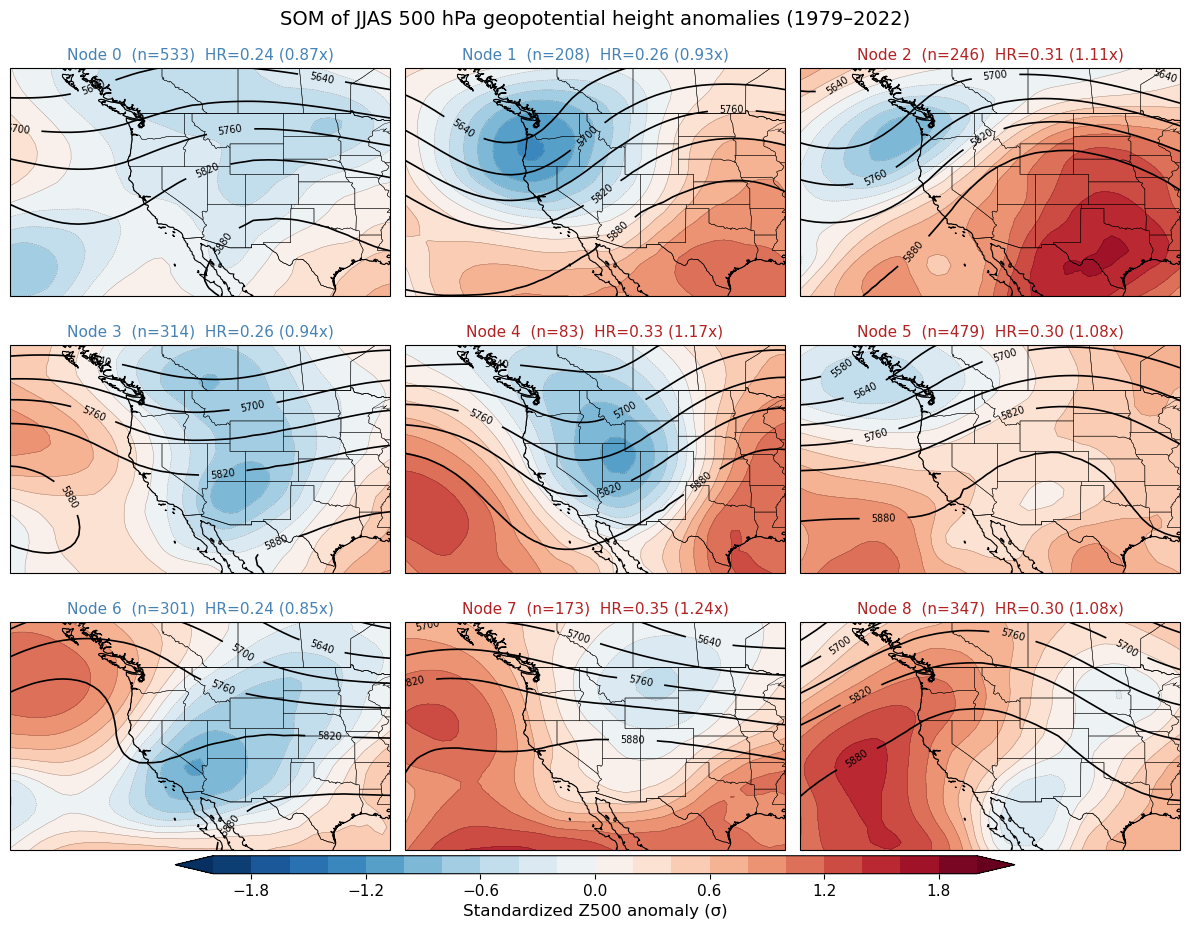

In [136]:
# build hit rate dict for easy lookup

hit_rate_dict = {}

for node_id in range(SOM_ROWS * SOM_COLS):
    
    days_in_node = node_assignments_fireperiod[
        node_assignments_fireperiod['node_id'] == node_id
    
    ]['date']
    
    total = len(days_in_node)
    
    hits  = days_in_node.isin(fire_dates).sum()
    
    hit_rate_dict[node_id] = hits / total if total > 0 else 0

fig, axes = plt.subplots(
    
    SOM_ROWS, SOM_COLS,
    
    figsize=(4 * SOM_COLS, 3 * SOM_ROWS),
    
    subplot_kw={'projection': ccrs.PlateCarree()}
)

vmin, vmax = -2, 2

for row in range(SOM_ROWS):
    
    for col in range(SOM_COLS):
        
        ax = axes[row, col]
        
        node_id = row * SOM_COLS + col
        
        pattern = weights[row, col, :, :]
        
        n_days = (node_assignments_fireperiod['node_id'] == node_id).sum()
        
        hr      = hit_rate_dict[node_id]
        
        ratio   = hr / background_rate

        im = ax.contourf(
            
            lons, lats, pattern,
            
            levels=np.linspace(vmin, vmax, 21),
            
            cmap='RdBu_r',
            
            extend='both',
            
            transform=ccrs.PlateCarree())
        
        ax.contour(
            
            lons, lats, pattern,
            
            levels=np.linspace(vmin, vmax, 21),
            
            colors='k', linewidths=0.3, alpha=0.4,
            
            transform=ccrs.PlateCarree())
        
        # add absolute geopotential height contours
        cs = ax.contour(
            
            lons, lats, geoph_composites[row, col],
            
            levels=np.arange(5400, 6000, 60),   # typical 500hPa range in meters
            
            colors='black',
            
            linewidths=1.2,
            
            transform=ccrs.PlateCarree())
            
        ax.clabel(cs, inline=True, fontsize=7, fmt='%d')
        
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        
        ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
        
        ax.add_feature(cfeature.STATES,    linewidth=0.3)

        # color the title red if above background, blue if below
        
        title_color = 'firebrick' if ratio > 1.0 else 'steelblue'
        
        ax.set_title(
            
            f"Node {node_id}  (n={n_days})  HR={hr:.2f} ({ratio:.2f}x)",
            
            fontsize=11, color=title_color)

plt.suptitle('SOM of JJAS 500 hPa geopotential height anomalies (1979–2022)',
             
             fontsize=14)

plt.tight_layout()

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')

cbar.set_label('Standardized Z500 anomaly (σ)', fontsize=12)

cbar.ax.tick_params(labelsize=11)

plt.savefig('som_z500_patterns.png', dpi=150, bbox_inches='tight')

plt.show()

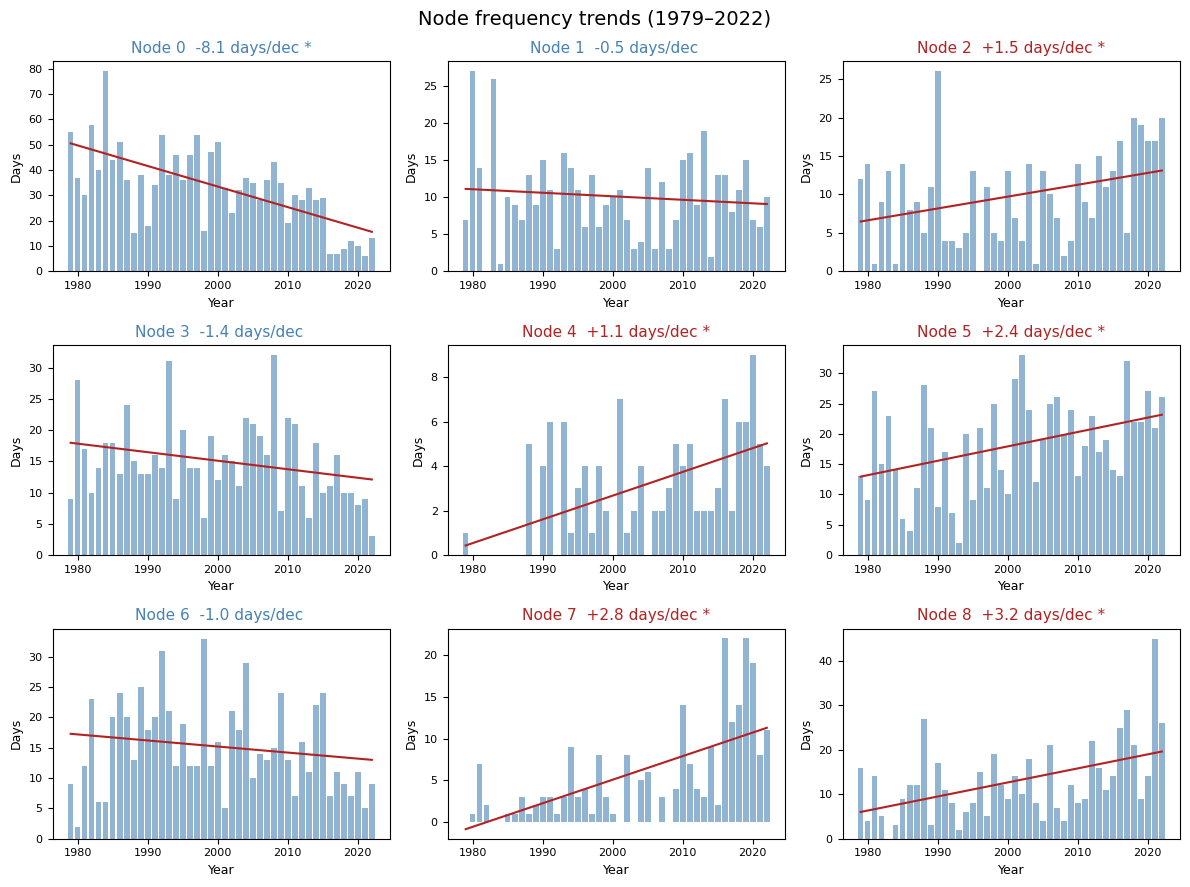

In [137]:
node_assignments['year'] = node_assignments['date'].dt.year

yearly_counts = node_assignments.groupby(['year', 'node_id']).size().unstack(fill_value=0)

fig, axes = plt.subplots(SOM_ROWS, SOM_COLS, figsize=(4*SOM_COLS, 3*SOM_ROWS), sharey=False)

for row in range(SOM_ROWS):
    
    for col in range(SOM_COLS):
        
        ax = axes[row, col]
        
        node_id = row * SOM_COLS + col
        
        counts  = yearly_counts[node_id].values
        
        years   = yearly_counts.index.values
        
        slope, intercept, r, p, se = stats.linregress(years, counts)

        ax.bar(years, counts, color='steelblue', alpha=0.6, width=0.8)
        
        ax.plot(years, slope * years + intercept, color='firebrick', linewidth=1.5)

        trend_per_decade = slope * 10
        
        sig = '*' if p < 0.05 else ''
        
        title_color = 'firebrick' if slope > 0 else 'steelblue'
        
        ax.set_title(
            
            f"Node {node_id}  {trend_per_decade:+.1f} days/dec {sig}",
            
            fontsize=11, color=title_color)
        
        ax.set_xlabel('Year', fontsize=9)
        
        ax.set_ylabel('Days', fontsize=9)
        
        ax.tick_params(labelsize=8)

plt.suptitle('Node frequency trends (1979–2022)', fontsize=14)

plt.tight_layout()

plt.savefig('som_node_trends.png', dpi=150, bbox_inches='tight')

plt.show()